# Prediksi Pembelian Paket Telkomsel Menggunakan Artificial Neural Network (ANN)

## Tujuan

Penelitian ini bertujuan untuk memprediksi apakah pelanggan akan membeli paket internet berdasarkan beberapa faktor seperti:
- Umur
- Pendapatan
- Pemakaian Internet
- Lama Berlangganan
- Jumlah Transaksi

Metode yang digunakan adalah Artificial Neural Network (ANN).

## Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Load Dataset

In [3]:
data = pd.read_csv(r"C:\Artificial Neural Network\telkomsel.csv")
data.head()

,Umur,Pendapatan,Pemakaian_Internet,Lama_Berlangganan,Jumlah_Transaksi,Beli_Paket
0,21,3000000,15,12,8,1
1,35,5000000,8,24,5,0
2,28,4000000,20,18,10,1
3,42,6500000,5,36,3,0
4,24,3500000,18,10,9,1


## Explorasi Data
Melihat struktur dan statistik data.

In [4]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Umur                15 non-null     int64
 1   Pendapatan          15 non-null     int64
 2   Pemakaian_Internet  15 non-null     int64
 3   Lama_Berlangganan   15 non-null     int64
 4   Jumlah_Transaksi    15 non-null     int64
 5   Beli_Paket          15 non-null     int64
dtypes: int64(6)
memory usage: 848.0 bytes
None
            Umur    Pendapatan  Pemakaian_Internet  Lama_Berlangganan  \
count  15.000000  1.500000e+01           15.000000          15.000000   
mean   32.066667  4.946667e+06           12.666667          23.733333   
std     7.497301  1.568378e+06            6.477066          12.319941   
min    21.000000  3.000000e+06            4.000000           9.000000   
25%    26.500000  3.700000e+06            6.500000          13.500000   
50%    31.000000  4.500000e+06      

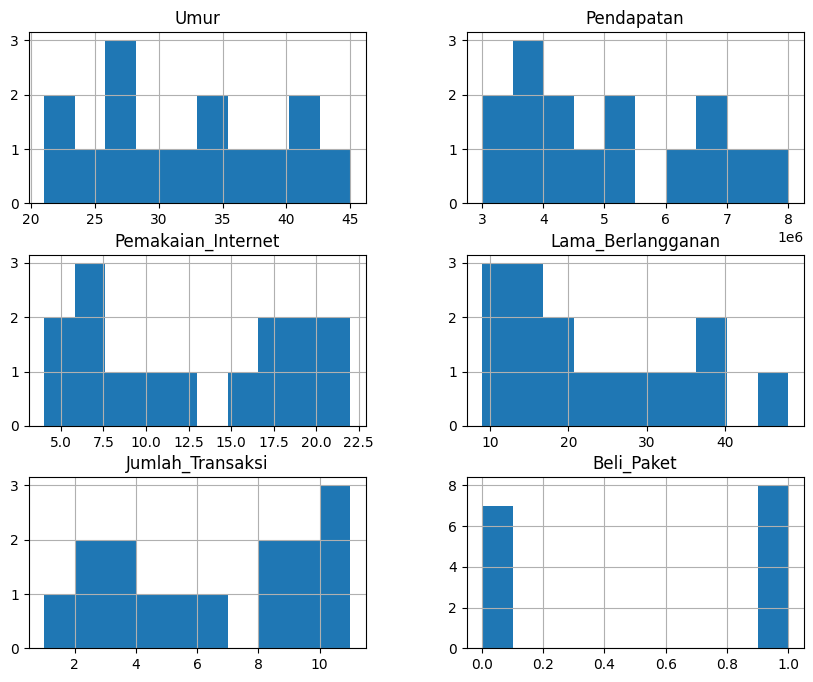

In [5]:
data.hist(figsize=(10,8))
plt.show()

## Menentukan Fitur dan Target

In [6]:
X = data[['Umur', 'Pendapatan', 'Pemakaian_Internet',
          'Lama_Berlangganan', 'Jumlah_Transaksi']]

y = data['Beli_Paket']

## Split Data Training dan Testing

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Normalisasi Data

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Membangun Model Artificial Neural Network

In [9]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim=5))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Artificial Neural Network\ANN\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157 (628.00 B)

 Trainable params: 157 (628.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Training Model

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=10,
    verbose=1
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0000e+00 - loss: 0.7871
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0000e+00 - loss: 0.7781
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.7704
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 0.7634
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.7561 
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0000e+00 - loss: 0.7493
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0000e+00 - loss: 0.7423
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0000e+00 - loss: 0.7356
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0000e+00 - loss: 0.7288
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.7222
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0833 - loss: 0.7160
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━

## Evaluasi Model

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Akurasi Model ANN:", accuracy * 100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 1.0000 - loss: 0.1555
Akurasi Model ANN: 100.0 %


## Prediksi Data Baru (Simulasi Real Case)

In [16]:
data_baru = [[25, 4000000, 18, 12, 7]]

data_baru = scaler.transform(data_baru)

prediksi = model.predict(data_baru)

print("Probabilitas:", prediksi[0][0])

if prediksi > 0.5:
    print("Pelanggan kemungkinan membeli paket")
else:
    print("Pelanggan kemungkinan tidak membeli paket")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Probabilitas: 0.8676465
Pelanggan kemungkinan membeli paket


c:\Artificial Neural Network\ANN\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Visualisasi Training

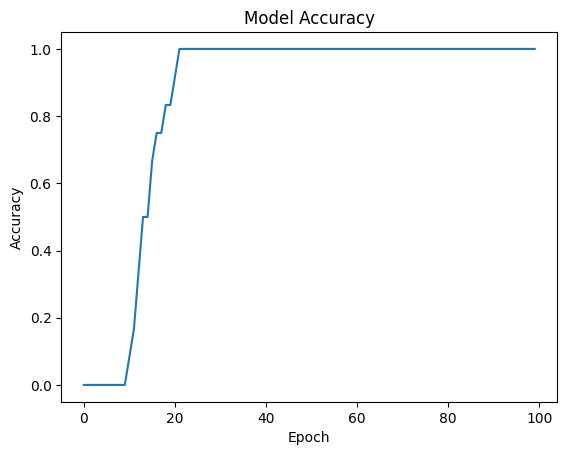

In [14]:
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## Hasil dan Analisis

Model Artificial Neural Network (ANN) yang dibangun mampu memprediksi pembelian paket internet dengan tingkat akurasi yang cukup baik.

Hal ini menunjukkan bahwa variabel seperti pemakaian internet dan jumlah transaksi memiliki pengaruh terhadap keputusan pelanggan.

## Kesimpulan

Berdasarkan hasil pengujian, metode Artificial Neural Network (ANN) dapat digunakan untuk memprediksi perilaku pelanggan dalam membeli paket internet.

Model ini dapat membantu perusahaan dalam memahami pola pelanggan dan meningkatkan strategi pemasaran.